<a href="https://colab.research.google.com/github/elisabethribeiro/analise-spotify-python/blob/main/Projeto_Final_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciclo 15 - Projeto Final — Análise Exploratória de Músicas do Spotify (2022)


**Objetivo**: Identificar quais gêneros musicais possuem maior e menor
popularidade no Spotify

**Justificativa**: Entender o que diferencia esses extremos e se há alguma relação entre suas características

Dataset Spotify: https://drive.google.com/file/d/1G1TKSidyKCrPfLMike1ECPRG4JiBEvEr/view?usp=sharing

## Etapas do Projeto

### 1. Importação e exploração inicial

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
# Carregar o dataset
df = pd.read_csv('/content/drive/MyDrive/Tecnologia/2026/pretalab-dados/spotify_dataset.csv', index_col=0)

### 1.1 Inspeção Básica

In [84]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [85]:
print(f"O dataset original possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset original possui 114000 linhas e 20 colunas.


In [86]:
df.describe() # min, max, média, quartis de todas as colunas numéricas

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [87]:
df.info()  # tipos de dados e valores nulos

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [88]:
#quantos gêneros existem? qual a popularidade mínima, máxima e média?
generos_total = df['track_genre'].nunique()
print(f"Total de gêneros únicos: {generos_total}")
print(f"Total de músicas: {len(df):,}")
print(f"Popularidade — mín: {df['popularity'].min()} | max: {df['popularity'].max()} | média: {df['popularity'].mean():.1f}")
print("\nGêneros no dataset:")
print(df['track_genre'].unique())

Total de gêneros únicos: 114
Total de músicas: 114,000
Popularidade — mín: 0 | max: 100 | média: 33.2

Gêneros no dataset:
['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-rock' 'punk-rock

Durante a exploração inicial foi possível identificar:
1. Os diferentes tipos de dados que contém o dataset (número inteiro, texto, número decimal e booleanos)
2. Número total de linhas (114000) e colunas (20)
3. Total de músicas (114000) e gêneros musicais (114)
4. Popularidade — mín: 0 | max: 100 | média: 33.2


### 2. Limpeza e preparação de dados

In [89]:
print(f"Valores nulos: {df.isnull().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Valores nulos: 3
Linhas duplicadas: 450


In [90]:
# Removendo nulos e duplicados
df_clean = df.dropna().drop_duplicates()

# Padronizando gêneros para minúsculas
df_clean['track_genre'] = df_clean['track_genre'].str.lower()

# Criando nova coluna duration_min convertendo duration_ms para minutos.
df_clean['duration_min'] = df_clean['duration_ms'] / 60000

print(f"Limpeza finalizada {len(df_clean):,} músicas e {df_clean['track_genre'].nunique()} gêneros musicais")


Limpeza finalizada 113,549 músicas e 114 gêneros musicais


### 3. Análise descritiva e Visualização




In [91]:
# Agrupando as músicas por gênero e calculando a popularidade média
popularidade_por_genero = df_clean.groupby('track_genre')['popularity'].mean().round(1)

print("Total de gêneros analisados:", len(popularidade_por_genero))

Total de gêneros analisados: 114


### Quais são os 10 gêneros MAIS populares no Spotify?


In [92]:
# Os 10 gêneros mais populares
top10 = popularidade_por_genero.sort_values(ascending=False).head(10)

print("TOP 10:")
print(top10)

TOP 10:
track_genre
pop-film     59.3
k-pop        57.0
chill        53.7
sad          52.4
grunge       49.6
indian       49.5
anime        48.8
emo          48.1
pop          47.9
sertanejo    47.9
Name: popularity, dtype: float64


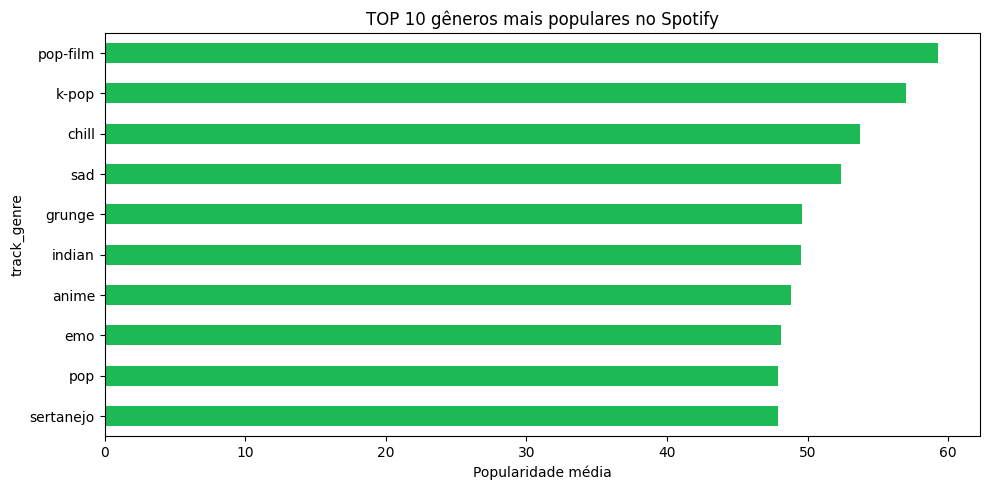

In [93]:
# Visualizando o TOP 10
plt.figure(figsize=(10, 5))

top10.sort_values().plot(kind='barh', color='#1DB954')

plt.title('TOP 10 gêneros mais populares no Spotify')
plt.xlabel('Popularidade média')
plt.tight_layout()
plt.show()

####O gráfico mostra que gêneros como pop-film, k-pop e chill lideram em popularidade, com médias próximas de 50–60 pontos, indicando forte aceitação e consumo dentro da plataforma.

### Quais são os 10 gêneros MENOS populares no Spotify?


In [94]:
# Os 10 gêneros menos populares
bottom10 = popularidade_por_genero.sort_values(ascending=True).head(10)
print("\n10 MENOS POPULARES:")
print(bottom10)


10 MENOS POPULARES:
track_genre
iranian            2.2
romance            3.5
latin              8.4
detroit-techno    11.2
chicago-house     12.3
classical         13.5
jazz              13.6
grindcore         14.6
kids              14.9
idm               15.8
Name: popularity, dtype: float64


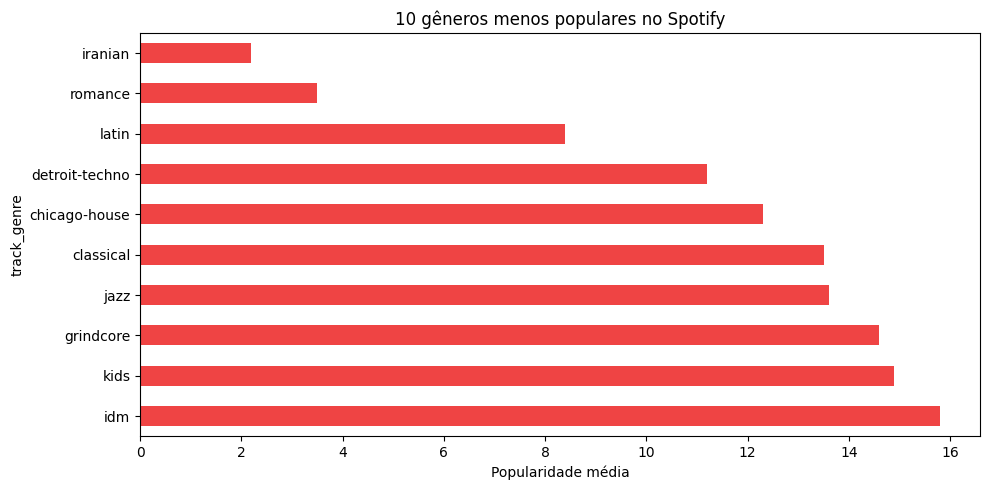

In [95]:
# Visualizando os gêneros menos populares
plt.figure(figsize=(10, 5))

bottom10.sort_values(ascending=False).plot(kind='barh', color='#ef4444')

plt.title('10 gêneros menos populares no Spotify')
plt.xlabel('Popularidade média')
plt.tight_layout()
plt.show()

####Os gêneros menos populares apresentam médias significativamente mais baixas (entre 2 e 16), destacando nichos como iranian, jazz e classical, que possuem menor alcance no Spotify.

### As características de cada gênero influenciam em sua popularidade?


In [96]:
#nomes dos gêneros de cada grupo
generos_top    = top10.index.tolist()
generos_bottom = bottom10.index.tolist()

#filtro do dataset para cada grupo
df_top    = df_clean[df_clean['track_genre'].isin(generos_top)]
df_bottom = df_clean[df_clean['track_genre'].isin(generos_bottom)]

#média de cada característica
caracteristicas = ['danceability', 'energy', 'valence', 'acousticness']

media_top    = df_top[caracteristicas].mean().round(2)
media_bottom = df_bottom[caracteristicas].mean().round(2)

print("Características — Top 10:")
print(media_top)
print("\nCaracterísticas — 10 menos populares:")
print(media_bottom)

Características — Top 10:
danceability    0.60
energy          0.62
valence         0.48
acousticness    0.35
dtype: float64

Características — 10 menos populares:
danceability    0.54
energy          0.57
valence         0.43
acousticness    0.37
dtype: float64


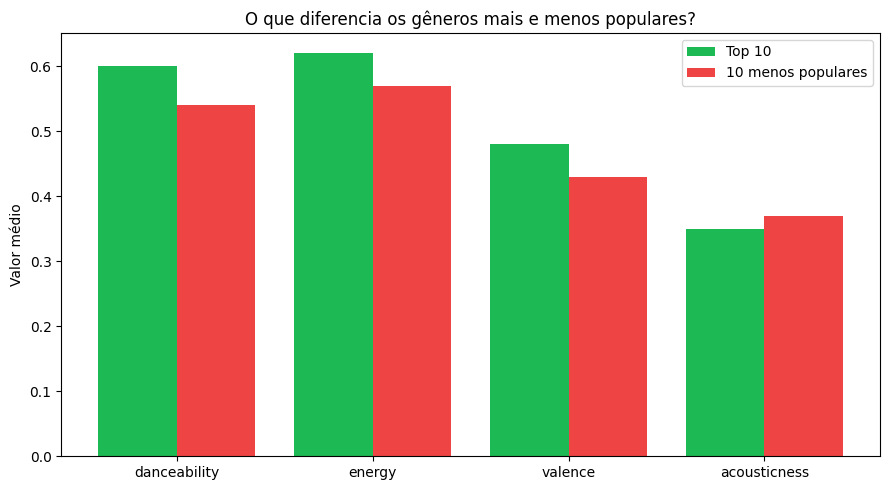

In [97]:
# comparação das características
import numpy as np

x = np.arange(len(caracteristicas))

plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, media_top,    0.4, label='Top 10',    color='#1DB954')
plt.bar(x + 0.2, media_bottom, 0.4, label='10 menos populares', color='#ef4444')

plt.xticks(x, caracteristicas)
plt.title('O que diferencia os gêneros mais e menos populares?')
plt.ylabel('Valor médio')
plt.legend()
plt.tight_layout()
plt.show()

####Gêneros mais populares possuem maiores médias de danceability e energy, enquanto os menos populares apresentam maior acousticness, evidenciando diferenças claras no perfil sonoro.

###Como a popularidade está distribuída entre todas as músicas?

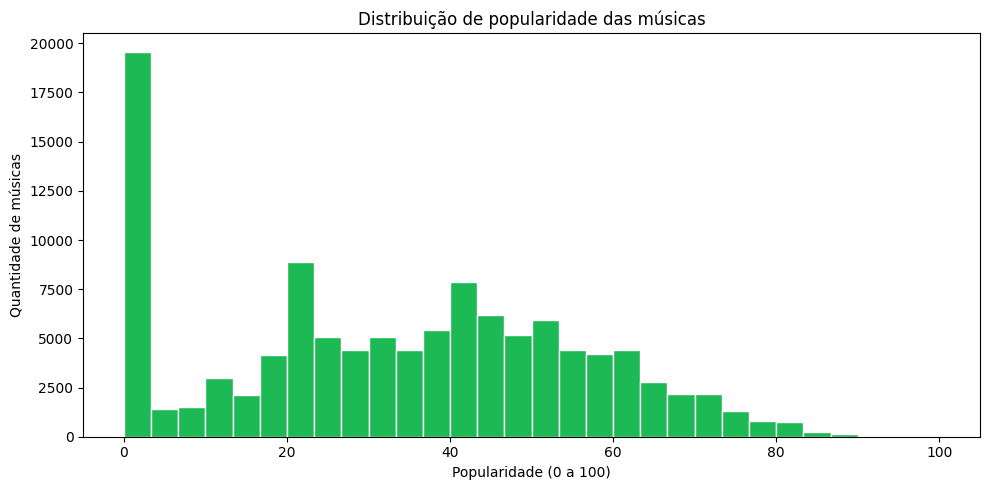

In [98]:
#Histograma de popularidade
plt.figure(figsize=(10, 5))

plt.hist(df_clean['popularity'], bins=30, color='#1DB954', edgecolor='white')

plt.title('Distribuição de popularidade das músicas')
plt.xlabel('Popularidade (0 a 100)')
plt.ylabel('Quantidade de músicas')
plt.tight_layout()
plt.show()

####A distribuição da popularidade é concentrada em valores mais baixos, com poucas músicas atingindo altos níveis, indicando que a maioria das faixas no Spotify tem baixa popularidade.

### Boxplot da duração das músicas


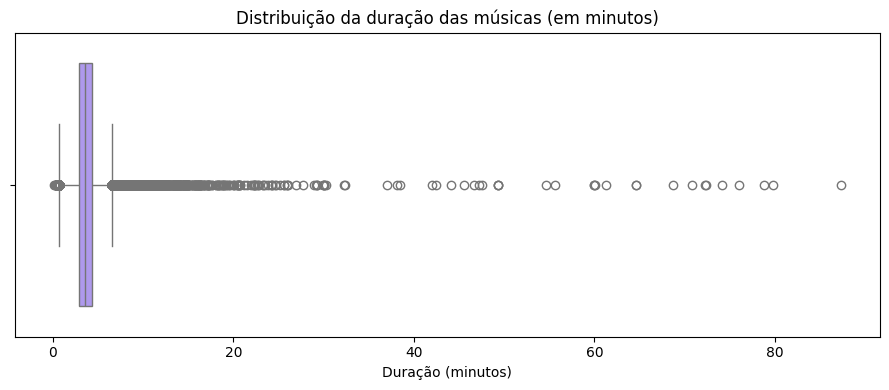

Duração média: 3.8 minutos
Menor duração: 0.1431 | Maior: 87.28825


In [99]:
plt.figure(figsize=(9, 4))

sns.boxplot(x=df_clean['duration_min'], color='#a78bfa')

plt.title('Distribuição da duração das músicas (em minutos)')
plt.xlabel('Duração (minutos)')
plt.tight_layout()
plt.show()

print("Duração média:", df_clean['duration_min'].mean().round(2), "minutos")
print("Menor duração:", df_clean['duration_min'].min(), "| Maior:", df_clean['duration_min'].max())

####A duração média das músicas é de 3.8 minutos, no entanto, há valores extremos, como músicas muito curtas (0.14 minutos) e muito longas (87.28 minutos), que podem ser considerados outliers e influenciar a análise.

In [100]:
top_max = df_clean[['track_name', 'artists', 'duration_min','track_genre', 'popularity']]\
    .sort_values(by='duration_min', ascending=False) \
    .head(10)

top_max

,track_name,artists,duration_min,track_genre,popularity
index,,,,,
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,87.288250,minimal-techno,35
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,79.817100,breakbeat,11
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,78.838367,detroit-techno,8
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,76.064950,minimal-techno,17
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,74.125333,chicago-house,11
13245,Live In Tokyo - Continuous Mix,Mark Farina,72.330433,chicago-house,11
13195,Greenhouse Construction,Mark Farina,72.245350,chicago-house,12
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,70.770100,drum-and-bass,15
101390,Ocean Waves Sounds,Ocean Sounds,68.670967,sleep,39


In [101]:
top_min = df_clean[['track_name', 'artists', 'duration_min','track_genre', 'popularity']] \
    .sort_values(by='duration_min', ascending=True) \
    .head(10)

top_min

,track_name,artists,duration_min,track_genre,popularity
index,,,,,
59310,The Exorsism Begins...,Leila Bela,0.143100,iranian,0
59812,V-4,Leila Bela,0.223100,iranian,0
59775,Screams for a Finale! (feat. Leila's Opera Class),Leila Bela;Leila's Opera Class,0.263333,iranian,0
16856,"Andante in C Major, K. 1a",Wolfgang Amadeus Mozart;Ingrid Haebler,0.290883,classical,0
16288,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",Robert Schumann;Pavel Nersessian,0.297100,classical,0
39233,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",Robert Schumann;Pavel Nersessian,0.297100,german,0
59306,V-7,Leila Bela,0.352000,iranian,0
59609,Shatter,Leila Bela,0.354000,iranian,0
11398,"Cello Suite No. 3, Op. 87: IX. Passacaglia (Ex...",Benjamin Britten;Steven Isserlis,0.371100,british,0


####Ao analisar as músicas mais longas, aparecem muitos mixes contínuos e faixas de DJs, que naturalmente têm duração maior.
####Já as mais curtas são trechos muito pequenos, algumas com menos de 1 minuto, o que pode indicar intervalo musical e partes de músicas.

### **DESAFIO EXTRA**: Quais características caminham juntas?



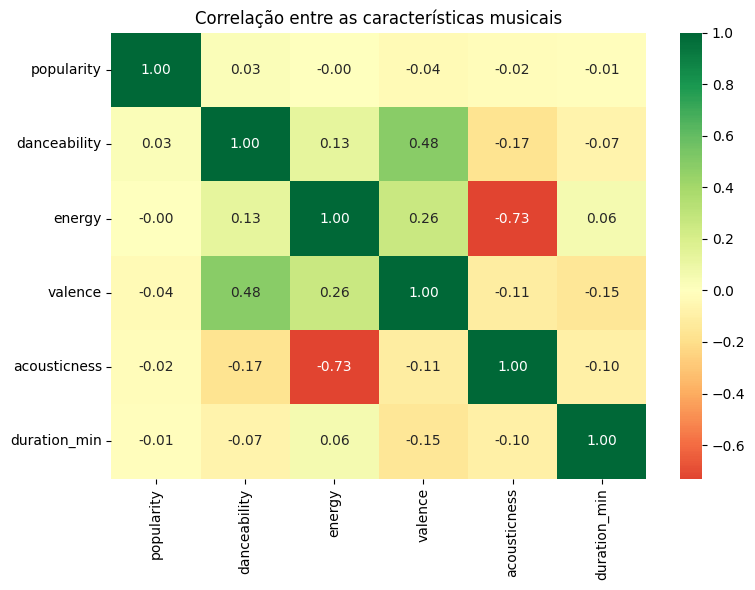

In [102]:
#heatmap
colunas = ['popularity', 'danceability', 'energy',
           'valence', 'acousticness', 'duration_min']

correlacao = df_clean[colunas].corr().round(2)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='RdYlGn',  # vermelho = negativo, verde = positivo
    center=0,        # zero - cor neutra (amarelo)
    fmt='.2f'
)

plt.title('Correlação entre as características musicais')
plt.tight_layout()
plt.show()

####As correlações não são muito fortes, o que indica que a popularidade não depende de apenas uma característica, mas de vários fatores juntos.

### Conclusão e interpretação

**Quais foram as principais descobertas?**

1. Os gêneros MAIS populares têm média de popularidade entre 47 e 59
2. Os MENOS populares ficam em torno de 2 a 16
3. Os gêneros do MAIS POPULARES tendem a ser mais dançantes e energéticos
4. Os MENOS POPULARES tendem a ter valores maiores de acousticness



**O que os dados revelam sobre o comportamento dos ouvintes no Spotify?**

É possível perceber que os ouvintes do Spotify preferem músicas mais animadas, com maior energia e mais fáceis de consumir no dia a dia, o que favorece gêneros mais populares e comerciais.

Gêneros muito específicos, como os que aparecem entre os menos populares, tendem a ser mais acústicos ou calmos, o que pode atrair um público menor dentro da plataforma, mas isso não significa que sejam piores, são somente diferentes.